# Bat Speed ~ Game Temperature

**Model:** `bat_speed ~ 1 + game_temp + (1 | park) + (1 | batter/p_throws)`

Does game temperature affect bat speed after controlling for batter identity, batter x pitcher-handedness, and ballpark?

- **Fixed effect of interest:** `game_temp`
- **Random effects:** `park` (venue), `batter` (individual baseline), `batter:p_throws` (L/R shift per batter)

In [1]:
# ── Configuration ──────────────────────────────────────────────
# Set REFIT = True to re-sample the model from scratch.
# Set REFIT = False to load saved InferenceData from disk
# and skip straight to diagnostics / analysis.
REFIT = True
IDATA_PATH = "bat_speed_temp_idata"

START = "2025-03-27"
END   = "2025-09-28"  # full 2025 regular season
DRAWS = 1000
TUNE  = 1000

In [2]:
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed

import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import requests

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline
%config InlineBackend.figure_format = "retina"

az.style.use("arviz-darkgrid")

# Reproducible, descriptive seed
RANDOM_SEED = sum(map(ord, "bat-speed-temp-v1"))
rng = np.random.default_rng(RANDOM_SEED)

## 1. Pull Statcast data

In [3]:
try:
    df = pd.read_feather("statcast_cache.feather")
    print(f"Loaded cached Statcast data: {len(df):,} rows")
except FileNotFoundError:
    from pybaseball import statcast, cache
    cache.enable()
    print(f"Pulling Statcast data from {START} to {END} ...")
    df = statcast(start_dt=START, end_dt=END)
    print(f"  Raw rows: {len(df):,}")

    # Regular season only
    df = df[df["game_type"] == "R"]
    print(f"  Regular season rows: {len(df):,}")

    # Keep only swings with bat_speed tracked
    df = df.dropna(subset=["bat_speed"])
    print(f"  Rows with bat_speed: {len(df):,}")

    df.to_feather("statcast_cache.feather")

print(f"Shape: {df.shape}")

Loaded cached Statcast data: 175,131 rows
Shape: (175131, 118)


## 2. Fetch game-day temperature

In [4]:
def fetch_weather_for_game(game_pk: int) -> dict:
    url = f"https://statsapi.mlb.com/api/v1.1/game/{game_pk}/feed/live"
    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        weather = r.json()["gameData"]["weather"]
        temp = weather.get("temp")
        return {"game_pk": game_pk, "game_temp": float(temp) if temp else None}
    except Exception:
        return {"game_pk": game_pk, "game_temp": None}


def fetch_all_weather(game_pks, max_workers: int = 8) -> pd.DataFrame:
    results = []
    total = len(game_pks)
    print(f"Fetching weather for {total:,} games ...")
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {pool.submit(fetch_weather_for_game, gp): gp for gp in game_pks}
        for i, fut in enumerate(as_completed(futures), 1):
            results.append(fut.result())
            if i % 200 == 0 or i == total:
                print(f"  {i}/{total}")
    weather_df = pd.DataFrame(results)
    hit_rate = weather_df["game_temp"].notna().mean()
    print(f"  Temperature found for {hit_rate:.0%} of games")
    return weather_df


game_pks = df["game_pk"].unique()
weather_df = fetch_all_weather(game_pks)

Fetching weather for 347 games ...
  200/347
  347/347
  Temperature found for 100% of games


## 3. Merge & prep modelling dataframe

In [5]:
mdf = df.merge(weather_df, on="game_pk", how="left")
mdf = mdf.dropna(subset=["game_temp"])

# Grouping factors as strings so Bambi treats them categorically
mdf["park"]     = mdf["home_team"].astype(str)
mdf["batter"]   = mdf["batter"].astype(str)
mdf["p_throws"] = mdf["p_throws"].astype(str)

# Keep only columns we need
mdf = (
    pl.from_pandas(mdf[["bat_speed", "game_temp", "park", "batter", "p_throws","game_pk"]])
    .group_by(["batter","p_throws","game_pk","park"])
    .agg(
        pl.col("bat_speed").mean().alias("bat_speed_mean"),
        pl.col("bat_speed").quantile(0.8).alias("bat_speed"),
        pl.col("game_temp").mean().alias("game_temp"),
    )
).to_pandas()

print(f"Modelling dataframe: {len(mdf):,} rows")
print(f"  Unique batters : {mdf['batter'].nunique()}")
print(f"  Unique parks   : {mdf['park'].nunique()}")
print(f"  Temp range     : {mdf['game_temp'].min():.0f}-{mdf['game_temp'].max():.0f} F")
print(f"  Bat speed range: {mdf['bat_speed'].min():.1f}-{mdf['bat_speed'].max():.1f} mph")

Modelling dataframe: 9,808 rows
  Unique batters : 611
  Unique parks   : 30
  Temp range     : 34-96 F
  Bat speed range: 4.3-87.8 mph


## 4. Build model & prior predictive check

In [6]:
model = bmb.Model(
    "bat_speed ~ 1 + game_temp + (1 | park) + (1 | batter/p_throws)",
    data=mdf,
)
model.build()
model

       Formula: bat_speed ~ 1 + game_temp + (1 | park) + (1 | batter/p_throws)
        Family: gaussian
          Link: mu = identity
  Observations: 9808
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 72.9508, sigma: 78.0288)
            game_temp ~ Normal(mu: 0.0, sigma: 1.1189)
        
        Group-level effects
            1|park ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 78.0288))
            1|batter ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 78.0288))
            1|batter:p_throws ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 78.0288))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 5.4694)

Sampling: [1|batter:p_throws_offset, 1|batter:p_throws_sigma, 1|batter_offset, 1|batter_sigma, 1|park_offset, 1|park_sigma, Intercept, bat_speed, game_temp, sigma]


Prior predictive bat_speed range: -1654.4 - 1287.6
Prior predictive bat_speed mean:  72.5


C:\Users\steph\AppData\Local\Temp\ipykernel_30032\2622717601.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


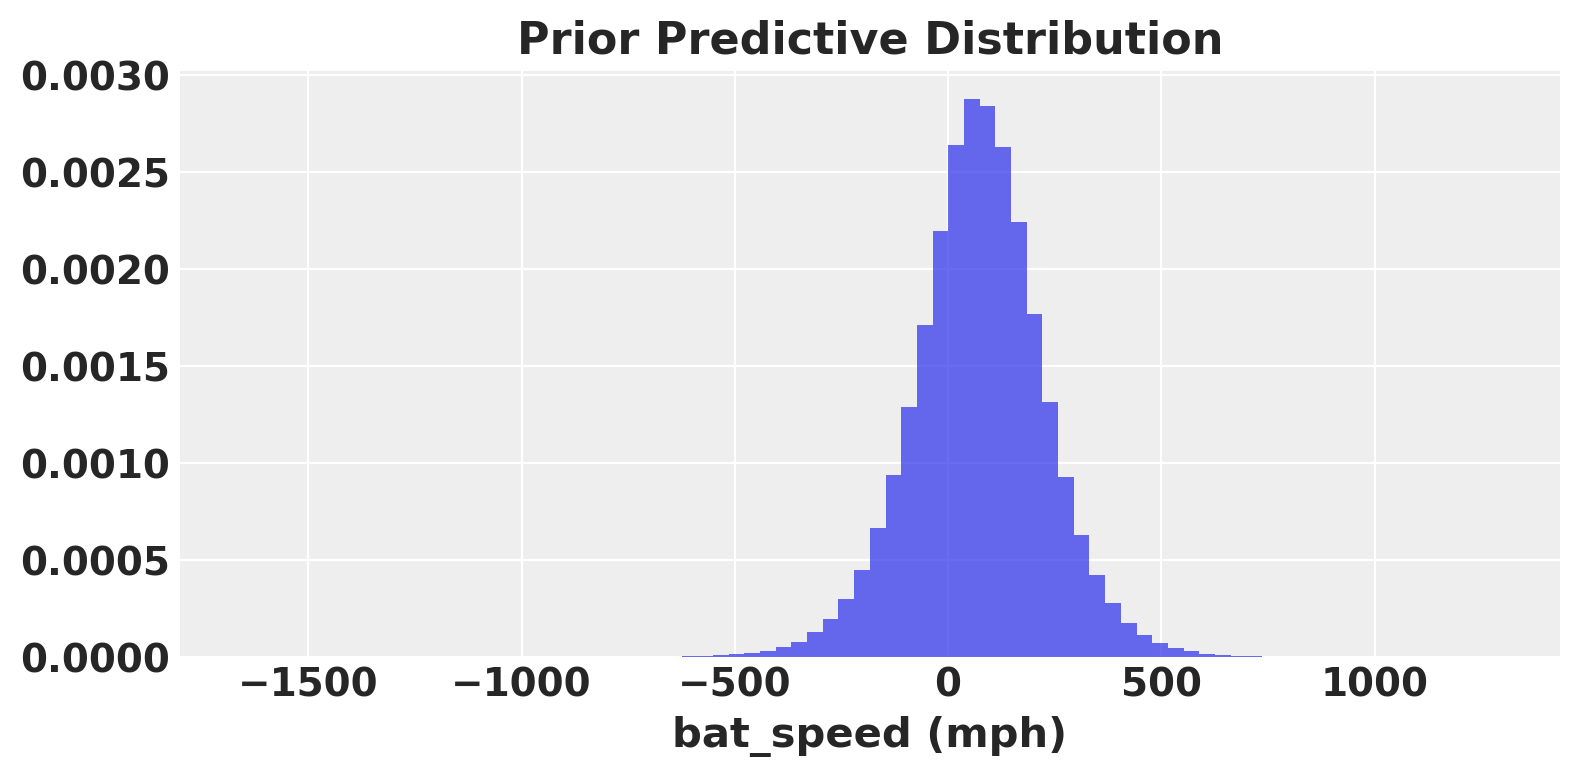

In [7]:
prior_idata = model.prior_predictive(random_seed=rng)
prior_pp = prior_idata.prior_predictive["bat_speed"]
print(f"Prior predictive bat_speed range: {float(prior_pp.min()):.1f} - {float(prior_pp.max()):.1f}")
print(f"Prior predictive bat_speed mean:  {float(prior_pp.mean()):.1f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_pp.values.flatten(), bins=80, alpha=0.7, density=True)
ax.set_xlabel("bat_speed (mph)")
ax.set_title("Prior Predictive Distribution")
plt.tight_layout()
plt.show()

## 5. Inference

Set `REFIT = False` in the config cell to skip sampling and load from disk.

In [8]:
if REFIT:
    # Bambi version check for nutpie kwarg name
    _bmb_version = tuple(int(x) for x in bmb.__version__.split(".")[:2])
    if _bmb_version >= (0, 14):
        sampler_kwargs = {"inference_method": "nutpie"}
    else:
        sampler_kwargs = {"nuts_sampler": "nutpie"}
    print(f"Bambi {bmb.__version__}: using {sampler_kwargs}")

    idata = model.fit(
        draws=DRAWS,
        tune=TUNE,
        random_seed=rng,
        **sampler_kwargs,
    )

    # Posterior predictive
    print("Running posterior predictive check ...")
    model.predict(idata, kind="pps")

    # Save immediately
    idata.to_json(IDATA_PATH)
    print(f"Saved InferenceData -> {IDATA_PATH}/")
else:
    idata = az.from_json(IDATA_PATH)
    print(f"Loaded InferenceData from {IDATA_PATH}/")

print(idata)

Bambi 0.16.0: using {'inference_method': 'nutpie'}


c:\Users\steph\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.19,31
,2000,0,0.20,31
,2000,0,0.22,31
,2000,0,0.21,31


Running posterior predictive check ...
Saved InferenceData -> bat_speed_temp_idata/
Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

Warmup iterations saved (warmup_*).


## 6. Convergence diagnostics

In [9]:
summary_all = az.summary(idata)
num_chains = idata.posterior.sizes["chain"]
rhat_max = float(summary_all["r_hat"].max())
ess_bulk_min = int(summary_all["ess_bulk"].min())
ess_tail_min = int(summary_all["ess_tail"].min())
n_div = int(idata.sample_stats["diverging"].sum())

rhat_ok = rhat_max <= 1.01
ess_ok = ess_bulk_min >= 100 * num_chains and ess_tail_min >= 100 * num_chains
div_ok = n_div == 0

print(f"R-hat max:      {rhat_max:.4f}  {'OK' if rhat_ok else 'PROBLEM'}")
print(f"ESS bulk min:   {ess_bulk_min}  {'OK' if ess_ok else 'LOW'}")
print(f"ESS tail min:   {ess_tail_min}")
print(f"Divergences:    {n_div}  {'OK' if div_ok else 'PROBLEM'}")
print()
if rhat_ok and ess_ok and div_ok:
    print("All diagnostics passed.")
else:
    print("WARNING: Diagnostics flagged issues -- inspect before interpreting.")

R-hat max:      1.0100  OK
ESS bulk min:   659  OK
ESS tail min:   990
Divergences:    0  OK

All diagnostics passed.


C:\Users\steph\AppData\Local\Temp\ipykernel_30032\616707870.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


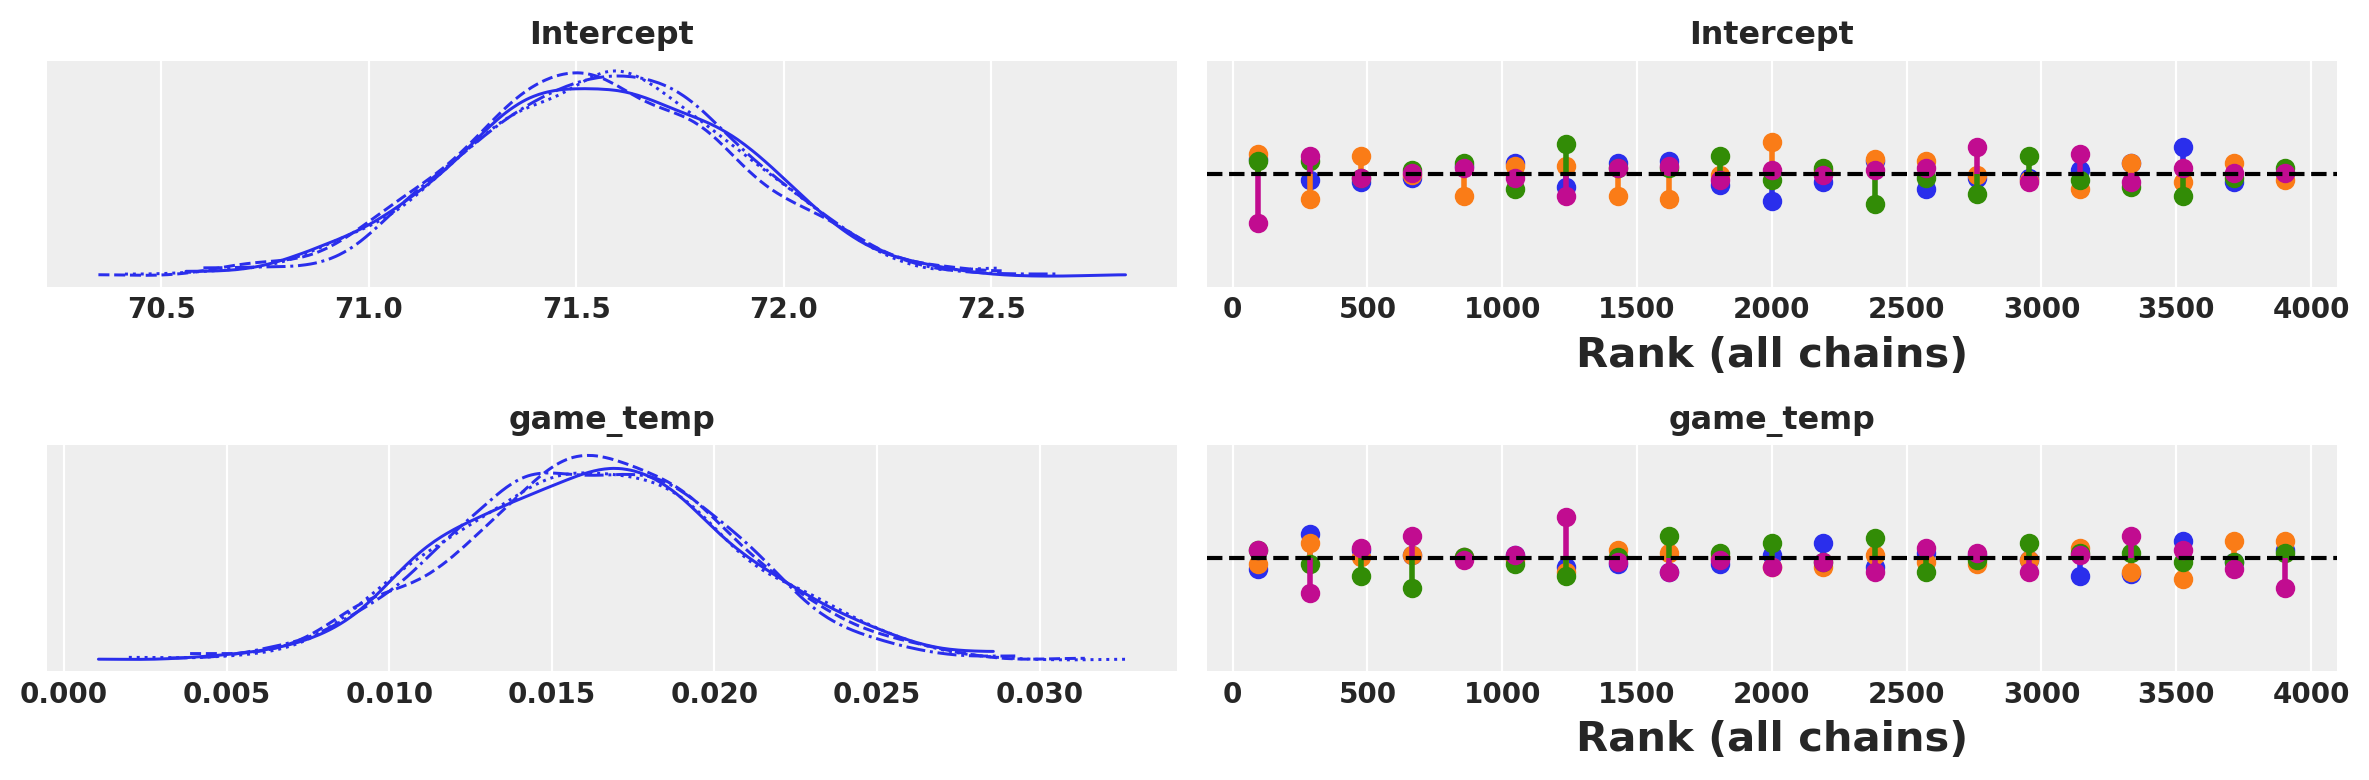

In [10]:
az.plot_trace(idata, var_names=["Intercept", "game_temp"], kind="rank_vlines")
plt.tight_layout()
plt.show()

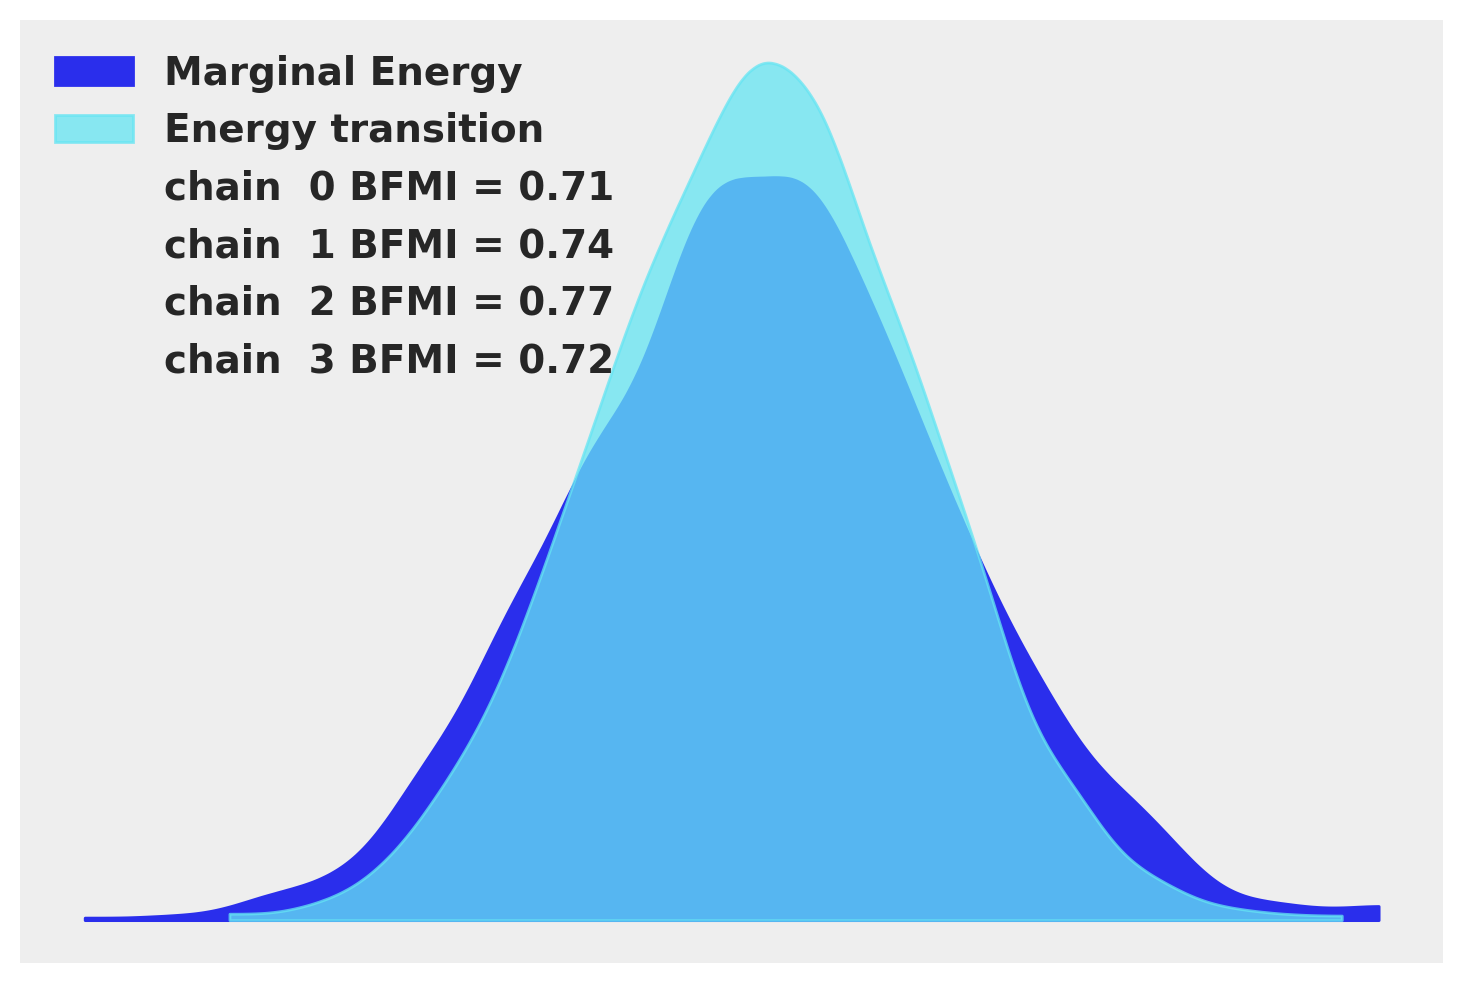

In [11]:
az.plot_energy(idata)
plt.show()

## 7. Posterior summary

In [12]:
print("Fixed effects (94% HDI)")
print("=" * 60)
az.summary(idata, var_names=["Intercept", "game_temp"], hdi_prob=0.94)

Fixed effects (94% HDI)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,71.560,0.326,70.973,72.165,0.005,0.005,4332.0,2814.0,1.0
game_temp,0.016,0.004,0.008,0.024,0.000,0.000,6501.0,3028.0,1.0


In [13]:
sd_vars = [v for v in idata.posterior.data_vars if "sigma" in v.lower()]
if sd_vars:
    print("Group-level standard deviations (94% HDI)")
    print("=" * 60)
    display(az.summary(idata, var_names=sd_vars, hdi_prob=0.94))

Group-level standard deviations (94% HDI)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_log__,1.517,0.008,1.503,1.532,0.000,0.000,4575.0,2955.0,1.00
1|park_sigma_log__,-2.274,1.057,-4.171,-0.926,0.036,0.052,1178.0,990.0,1.00
1|batter_sigma_log__,0.977,0.042,0.900,1.058,0.001,0.001,1274.0,2077.0,1.01
1|batter:p_throws_sigma_log__,0.433,0.073,0.298,0.567,0.003,0.001,659.0,1534.0,1.01
sigma,4.557,0.035,4.493,4.626,0.001,0.001,4575.0,2955.0,1.00
1|park_sigma,0.142,0.086,0.000,0.282,0.002,0.001,1178.0,990.0,1.00
1|batter_sigma,2.660,0.111,2.461,2.881,0.003,0.002,1274.0,2077.0,1.01
1|batter:p_throws_sigma,1.546,0.112,1.347,1.763,0.004,0.002,659.0,1534.0,1.01


## 8. Model criticism

### Posterior predictive check

C:\Users\steph\AppData\Local\Temp\ipykernel_30032\1351808320.py:2: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\steph\AppData\Local\Temp\ipykernel_30032\1351808320.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
c:\Users\steph\anaconda3\envs\pymc_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


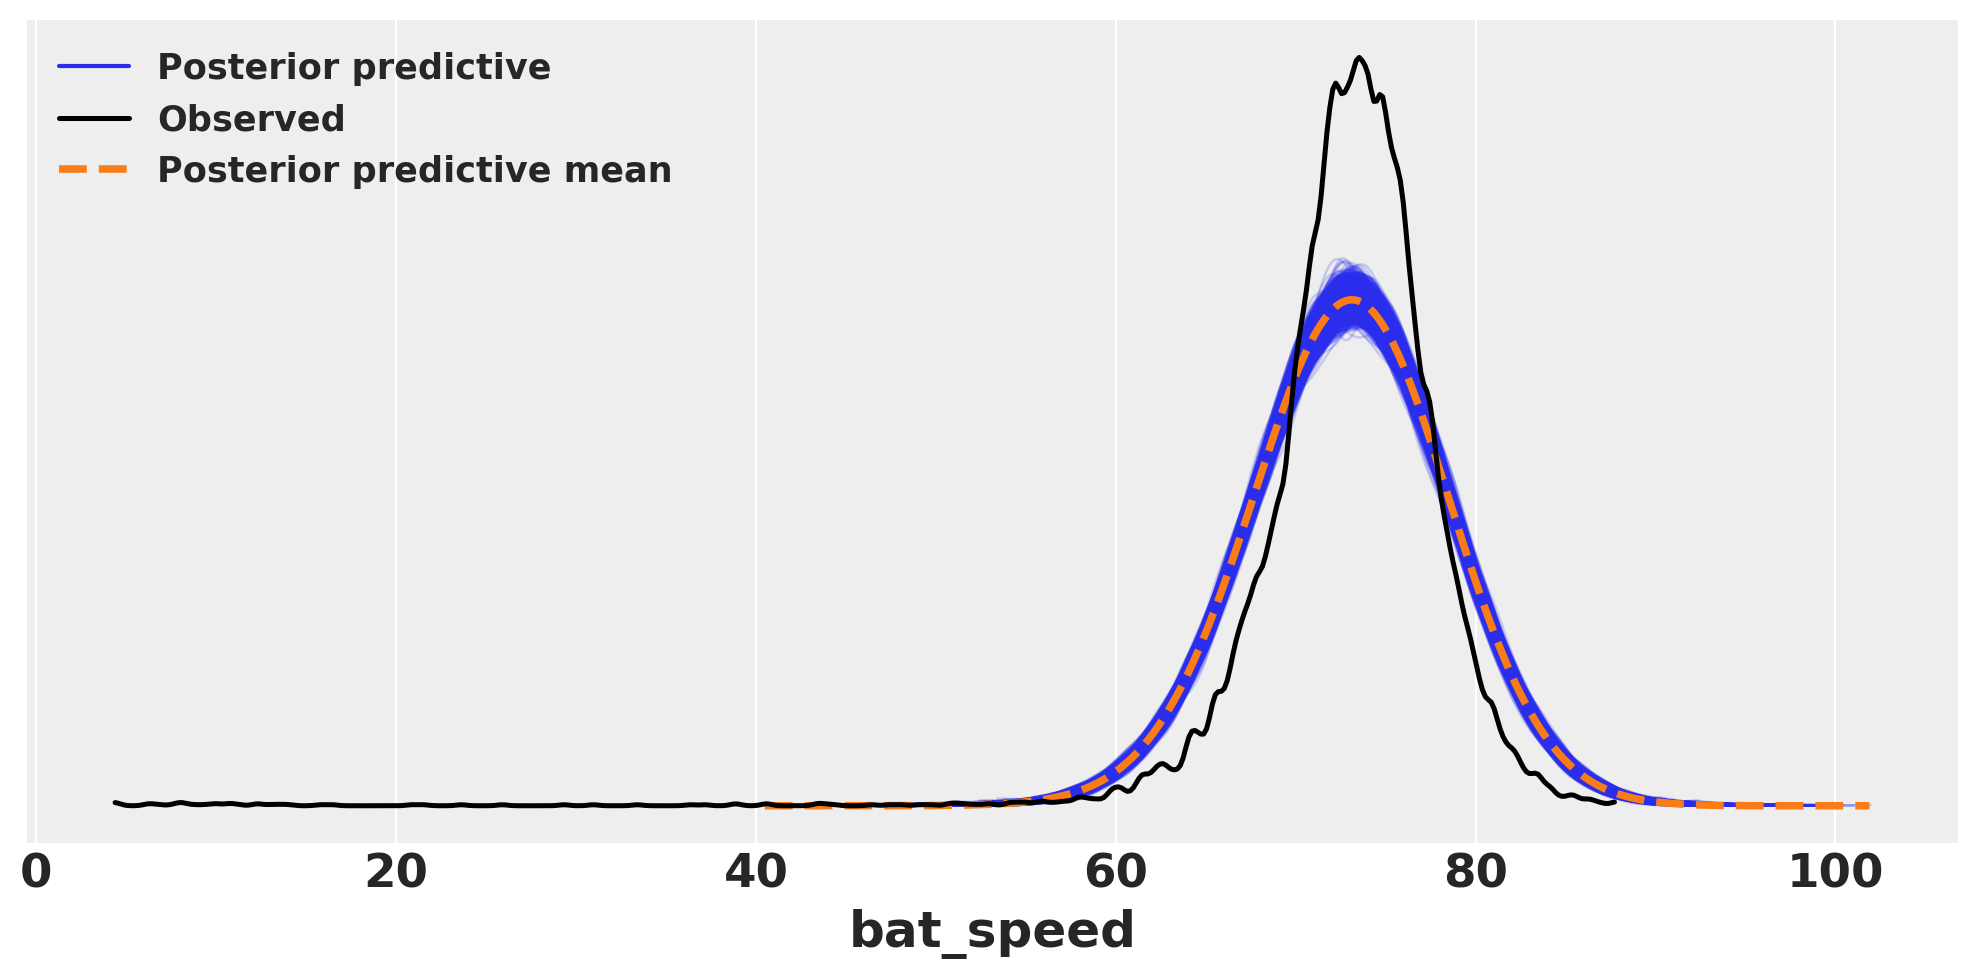

In [14]:
az.plot_ppc(idata, figsize=(10, 5))
plt.tight_layout()
plt.show()

### Calibration (PIT)

C:\Users\steph\AppData\Local\Temp\ipykernel_30032\70747834.py:4: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


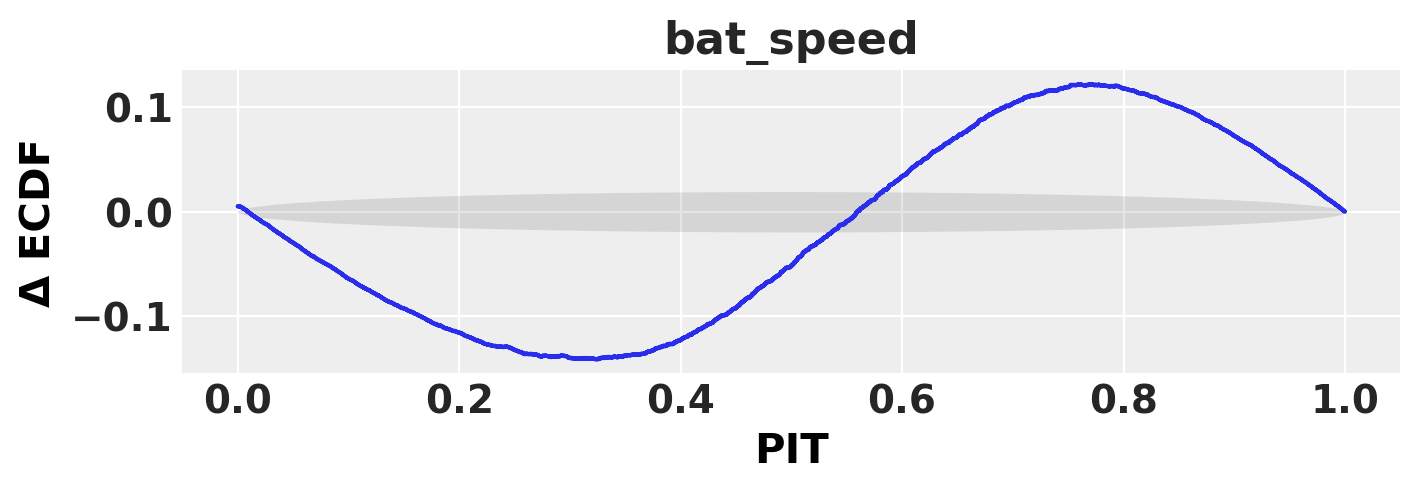

In [15]:
try:
    import arviz_plots as azp
    azp.plot_ppc_pit(idata)
    plt.tight_layout()
    plt.show()
except (ImportError, AttributeError):
    print("arviz-plots not available or too old for plot_ppc_pit; skipping PIT.")

## 9. Results — game_temp effect

C:\Users\steph\AppData\Local\Temp\ipykernel_30032\945070749.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


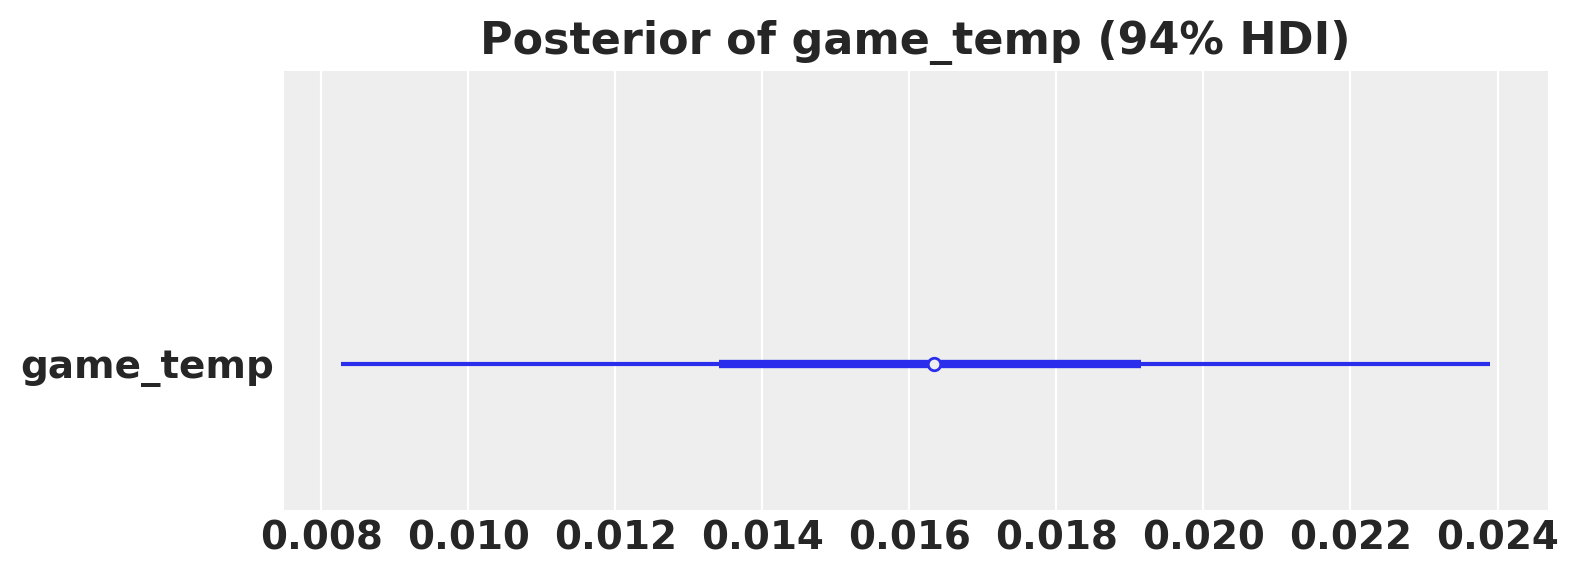

In [16]:
az.plot_forest(idata, var_names=["game_temp"], combined=True, hdi_prob=0.94, figsize=(8, 3))
plt.title("Posterior of game_temp (94% HDI)")
plt.tight_layout()
plt.show()

C:\Users\steph\AppData\Local\Temp\ipykernel_30032\2431993240.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


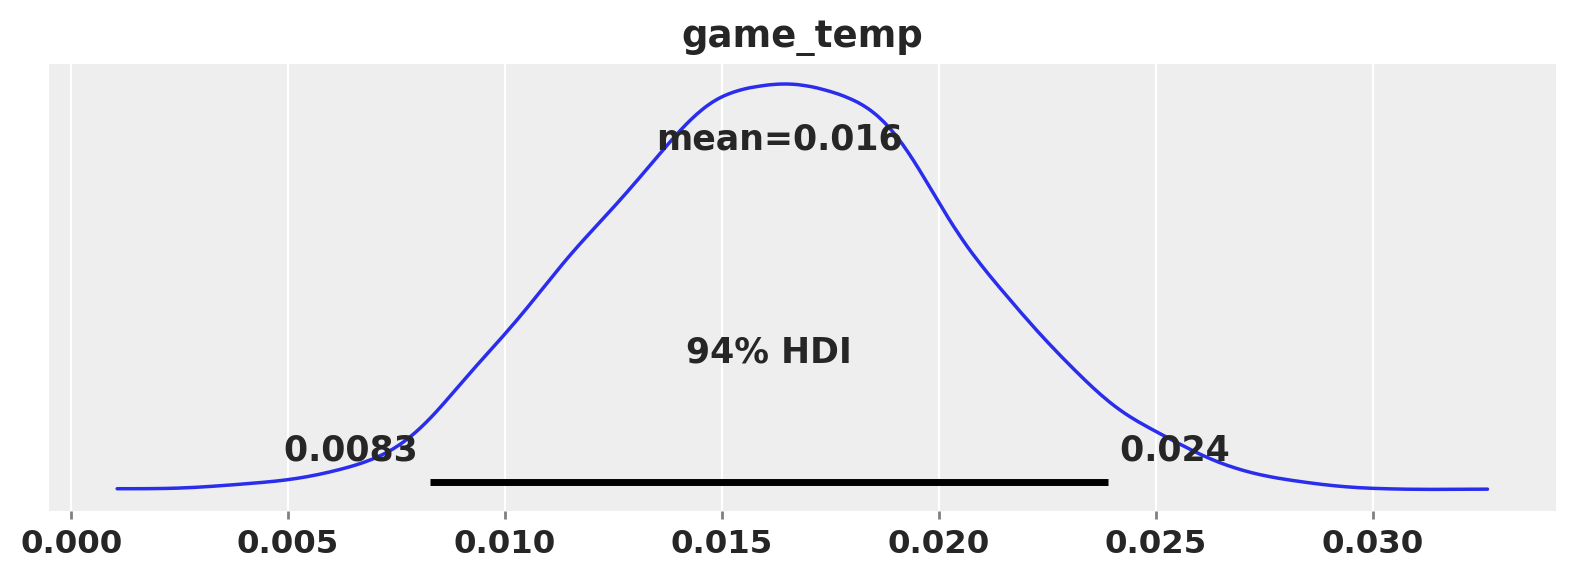

In [17]:
az.plot_posterior(idata, var_names=["game_temp"], hdi_prob=0.94, figsize=(8, 3))
plt.tight_layout()
plt.show()

In [ ]:
# Practical effect size: how much does bat speed change across the observed temp range?
temp_range = mdf["game_temp"].max() - mdf["game_temp"].min()
game_temp_posterior = idata.posterior["game_temp"]
effect_across_range = game_temp_posterior * temp_range

print(f"Observed temperature range: {mdf['game_temp'].min():.0f} - {mdf['game_temp'].max():.0f} F ({temp_range:.0f} F)")
print(f"Posterior mean effect per 1 F:          {float(game_temp_posterior.mean()):.4f} mph")
print(f"Posterior mean effect across full range: {float(effect_across_range.mean()):.2f} mph")

hdi_arr = az.hdi(effect_across_range.values.flatten(), hdi_prob=0.94)
print(f"94% HDI across full range:               [{hdi_arr[0]:.2f}, {hdi_arr[1]:.2f}] mph")

Observed temperature range: 34 - 96 F (62 F)
Posterior mean effect per 1 F:          0.0163 mph
Posterior mean effect across full range: 1.01 mph
94% HDI across full range:               [0.51, 1.48] mph
